# Preprocessing

Unlike datasets such as NPPAD where simulations start already in an anomalous state, each SKAB file contains a normal segment followed by an anomalous zone. The strategy adopted is therefore **per-file**: for each file, the portion with `anomaly==0` is used as the model training set, while the full sequence is used for evaluation. This ensures the model learns the normal distribution under the same operating conditions in which the anomaly occurs.

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
from sklearn.preprocessing import StandardScaler

DATA_PATH = "SKAB/data"

features = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 
            'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']

# Collect all anomalous files
all_files = []
for folder in ["valve1", "valve2", "other"]:
    folder_path = os.path.join(DATA_PATH, folder)
    for f in sorted(os.listdir(folder_path)):
        if f.endswith(".csv"):
            all_files.append(os.path.join(folder_path, f))

print(f"Total files: {len(all_files)}")

# Verify each file has a normal segment
for fpath in all_files:
    df = pd.read_csv(fpath, sep=";")
    n_normal = (df["anomaly"] == 0).sum()
    n_anomaly = (df["anomaly"] == 1).sum()
    print(f"{fpath.split('/')[-2]}/{fpath.split('/')[-1]}: {n_normal} normal, {n_anomaly} anomalous")

Total files: 34
valve1/0.csv: 746 normal, 401 anomalous
valve1/1.csv: 743 normal, 402 anomalous
valve1/10.csv: 745 normal, 401 anomalous
valve1/11.csv: 742 normal, 399 anomalous
valve1/12.csv: 741 normal, 399 anomalous
valve1/13.csv: 741 normal, 399 anomalous
valve1/14.csv: 740 normal, 399 anomalous
valve1/15.csv: 746 normal, 404 anomalous
valve1/2.csv: 738 normal, 337 anomalous
valve1/3.csv: 744 normal, 404 anomalous
valve1/4.csv: 746 normal, 349 anomalous
valve1/5.csv: 751 normal, 403 anomalous
valve1/6.csv: 749 normal, 405 anomalous
valve1/7.csv: 689 normal, 405 anomalous
valve1/8.csv: 744 normal, 400 anomalous
valve1/9.csv: 746 normal, 402 anomalous
valve2/0.csv: 731 normal, 394 anomalous
valve2/1.csv: 730 normal, 333 anomalous
valve2/2.csv: 734 normal, 395 anomalous
valve2/3.csv: 600 normal, 395 anomalous
other/1.csv: 557 normal, 188 anomalous
other/10.csv: 741 normal, 586 anomalous
other/11.csv: 739 normal, 451 anomalous
other/12.csv: 739 normal, 309 anomalous
other/13.csv: 658 n

## Feature analysis

We analyse the variance and structure of the features on the `anomaly-free.csv` file. With 8 features all having significant variance and none constant, aggressive dimensionality reduction is not needed — unlike NPPAD with 97 features. An exploratory PCA confirms that 6 components are needed for 95% of variance, offering no meaningful gain over the original 8 features.

/var/folders/z6/jc8k83792bgc1cl6r2fh8rt00000gn/T/ipykernel_11871/2493814320.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(variances.index, rotation=45, ha="right", fontsize=8)


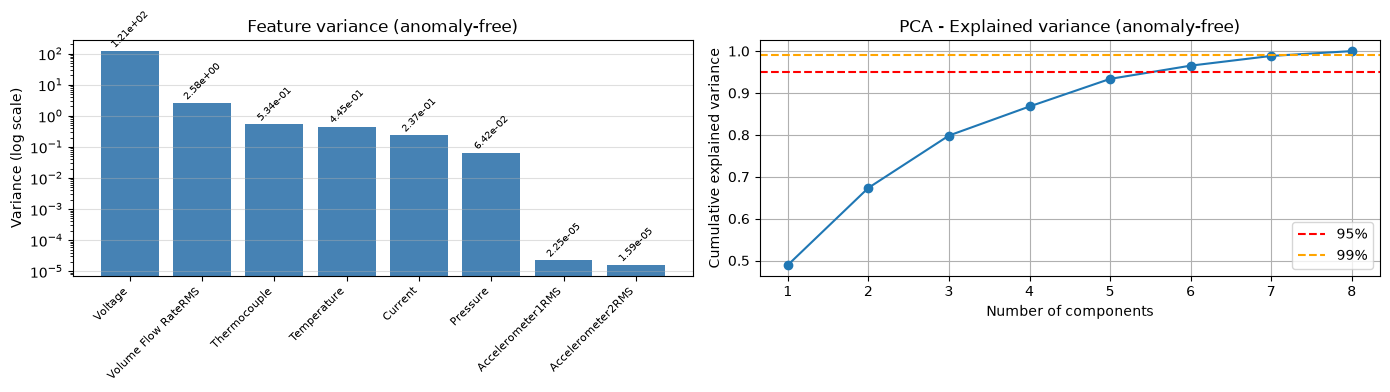

Components for 95%: 6
Components for 99%: 8


In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df_normal = pd.read_csv(os.path.join(DATA_PATH, "anomaly-free/anomaly-free.csv"), sep=";")

# Feature variance as bar chart
variances = df_normal[features].var().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart con scala log e valori
axes[0].bar(variances.index, variances.values, color="steelblue")
axes[0].set_yscale("log")
axes[0].set_xticklabels(variances.index, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Variance (log scale)")
axes[0].set_title("Feature variance (anomaly-free)")
axes[0].grid(axis="y", alpha=0.4)
for i, (name, val) in enumerate(variances.items()):
    axes[0].text(i, val * 1.3, f"{val:.2e}", ha="center", fontsize=7, rotation=45)

# PCA
scaler_exp = StandardScaler()
X_exp = scaler_exp.fit_transform(df_normal[features].values)
pca_full = PCA()
pca_full.fit(X_exp)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

axes[1].plot(range(1, len(cumvar)+1), cumvar, marker="o")
axes[1].axhline(y=0.95, color="red", linestyle="--", label="95%")
axes[1].axhline(y=0.99, color="orange", linestyle="--", label="99%")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("PCA - Explained variance (anomaly-free)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Components for 95%: {np.argmax(cumvar >= 0.95) + 1}")
print(f"Components for 99%: {np.argmax(cumvar >= 0.99) + 1}")

## Save preprocessing

We save the file list and feature names to `preprocessing.pkl` for reuse across all subsequent notebooks.

In [3]:
import pickle

features = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 
            'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']

all_files = []
for folder in ["valve1", "valve2", "other"]:
    folder_path = os.path.join(DATA_PATH, folder)
    for f in sorted(os.listdir(folder_path)):
        if f.endswith(".csv"):
            all_files.append(os.path.join(folder_path, f))

prep = {
    "features": features,
    "all_files": all_files,
    "data_path": DATA_PATH
}

with open("preprocessing.pkl", "wb") as f:
    pickle.dump(prep, f)

print("Preprocessing saved!")
print(f"Total files: {len(all_files)}")

Preprocessing saved!
Total files: 34
